# Customer Churn Analysis

## problem Statement 

The company is facing a severe customer churn crisis, with 47.4% of 64,374 subscribers cancelling their service, resulting in an estimated $18,991,722 in lost revenue and substantially higher customer acquisition costs.

## Objectives
1- What is the churn rate across age categories and gender, and which age-gender segment has the highest churn rate?

2- How does the churn rate vary by contract length (Monthly, Quarterly, Annual) and subscription type (Basic, Standard, Premium), and which factor differentiates churn more?

3- Which tenure months (1-60) have the highest and lowest churn rates, and does low tenure imply a high churn rate?

4- What percentage of customers had a payment delay exceeding 14 days across all customers, and how does the churn rate differ between high-delay and low-delay customers?

5- How does the churn rate vary with the number of support calls (0-10), and how does it differ between customers with more than 5 calls and those with 5 or fewer?


In [56]:
import pandas as pd 
import matplotlib.pyplot as plt

### Problem statement : 
The company is facing a severe customer churn crisis, with 47.4% of 64,374 subscribers canceling their service, resulting in an estimated $18,991,722 in lost revenue and substantially higher customer acquisition costs.

### Objectives:
1- What is the churn rate across age categories and gender, and which age-gender segment has the highest churn rate?

2- How does the churn rate vary by contract length (Monthly, Quarterly, Annual) and subscription type (Basic, Standard, Premium), and which factor differentiates churn more?

3- Which tenure months (1-60) have the highest and lowest churn rates, and does low tenure imply a high churn rate?

4- What percentage of customers had a payment delay exceeding 14 days across all customers, and how does the churn rate differ between high-delay and low-delay customers?

5- How does the churn rate vary with the number of support calls (0-10), and how does it differ between customers with more than 6 calls and those with 6 or fewer?


In [54]:
import pandas as pd 
import matplotlib.pyplot as plt


In [13]:
customer_churn=pd.read_csv("customer_churn.csv")

## Exploring the data
## Data info:

In [3]:
customer_churn.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
customer_churn.shape

(64374, 12)

In [5]:
customer_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [6]:
customer_churn.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## Data Handling

### Data Cleaning: check if there is missing values or dublicate rows 

In [7]:
customer_churn.duplicated().sum()

0

In [8]:
customer_churn.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

## Data analysis

In [9]:
customer_churn["Churn"]=customer_churn["Churn"].map({1:"yes",0: "no"})
customer_churn["Churn"]

0        yes
1         no
2         no
3         no
4         no
        ... 
64369    yes
64370    yes
64371    yes
64372    yes
64373    yes
Name: Churn, Length: 64374, dtype: str

In [10]:
customer_churn["Churn"].value_counts()


Churn
no     33881
yes    30493
Name: count, dtype: int64

##### Churn column

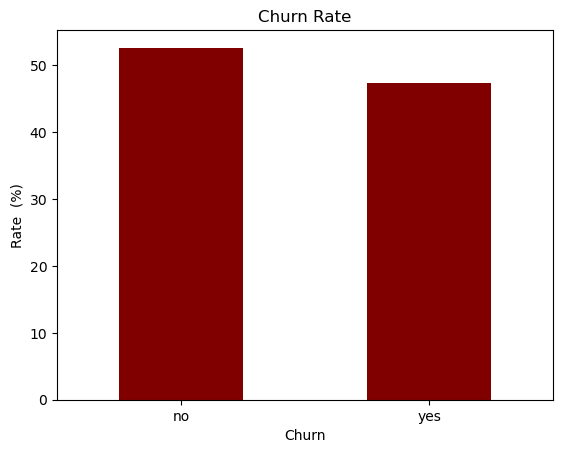

In [11]:
(customer_churn["Churn"].value_counts()/len(customer_churn)*100).plot(kind="bar", color="maroon")
plt.title("Churn Rate")
plt.ylabel("Rate  (%)")
plt.xticks(rotation=0)
plt.show()

In [14]:
customer_churn.groupby("Gender")["Churn"].mean()*100

Gender
Female    55.049050
Male      38.579661
Name: Churn, dtype: float64

In [15]:
customer_churn["age_category"]=pd.cut(customer_churn["Age"], [18, 29, 39, 49 , 65], labels=["18-28","29-38", "39-48", "49-65"])

In [16]:
customer_churn.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,age_category
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1,18-28
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0,39-48
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0,39-48
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,29-38
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0,49-65


#### What is the churn rate across age categories and gender, and which age-gender segment has the highest churn rate?


In [17]:
age_gender=customer_churn.groupby(["age_category", "Gender"])["Churn"].mean()*100

In [18]:
age_gender

age_category  Gender
18-28         Female    52.779248
              Male      35.090070
29-38         Female    52.573734
              Male      35.313531
39-48         Female    53.304598
              Male      34.527579
49-65         Female    59.030212
              Male      45.148552
Name: Churn, dtype: float64

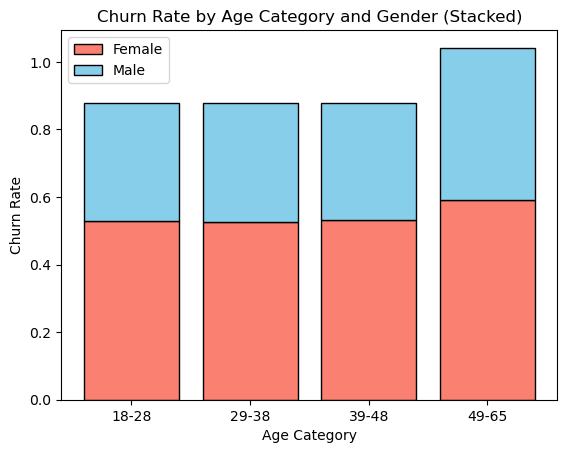

In [58]:
female_data = customer_churn[customer_churn["Gender"] == "Female"].groupby("age_category")['Churn'].mean()
male_data = customer_churn[customer_churn["Gender"] == "Male"].groupby("age_category")['Churn'].mean()

plt.bar(female_data.index, female_data, label="Female", color="salmon", edgecolor='black')
plt.bar(male_data.index, male_data, bottom=female_data, label="Male", color="skyblue", edgecolor="black")

plt.title("Churn Rate by Age Category and Gender (Stacked)")
plt.xlabel("Age Category")
plt.ylabel('Churn Rate')
plt.legend()
plt.show()

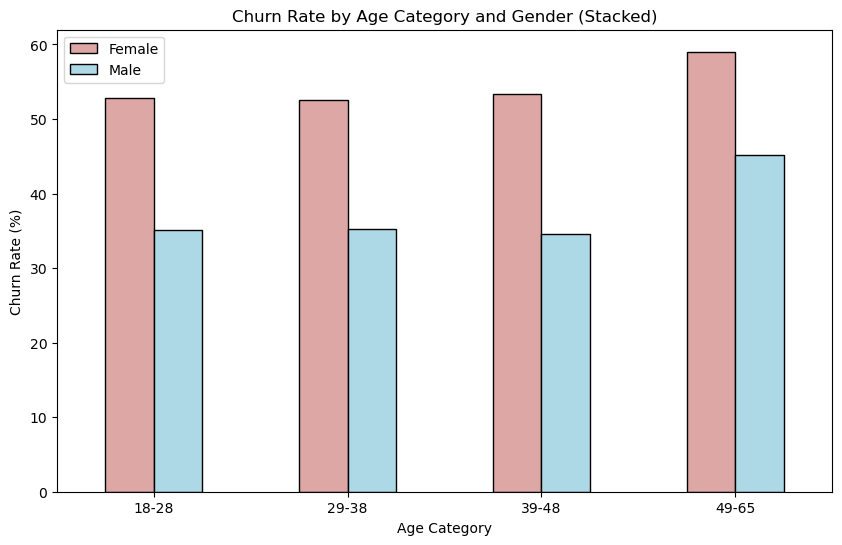

In [60]:
combined = pd.DataFrame({"Female": female_data*100, "Male": male_data*100})
combined.plot(kind="bar", color=['#DDA7A5', 'lightblue'], edgecolor="black", figsize=(10,6))
plt.title("Churn Rate by Age Category and Gender (Stacked)")
plt.xlabel("Age Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

#### How does the churn rate vary by contract length (Monthly, Quarterly, Annual) and subscription type (Basic, Standard, Premium), and which factor differentiates churn more?


In [21]:
sub=customer_churn.groupby(["Subscription Type","Contract Length"])["Churn"].mean()*100
sub

Subscription Type  Contract Length
Basic              Annual             47.132065
                   Monthly            52.109047
                   Quarterly          45.382395
Premium            Annual             45.639576
                   Monthly            50.870563
                   Quarterly          42.698573
Standard           Annual             45.874496
                   Monthly            51.850844
                   Quarterly          44.064877
Name: Churn, dtype: float64

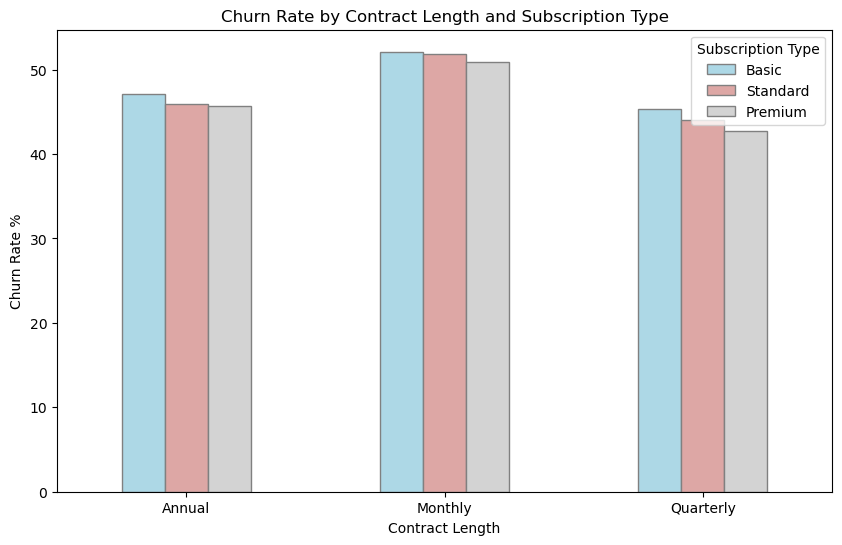

In [61]:
Basic_data = customer_churn[customer_churn["Subscription Type"] == "Basic"].groupby("Contract Length")["Churn"].mean()
Standard_data = customer_churn[customer_churn["Subscription Type"] == "Standard"].groupby("Contract Length")["Churn"].mean()
Premium_data = customer_churn[customer_churn["Subscription Type"] == 'Premium'].groupby("Contract Length")["Churn"].mean()

combined = pd.DataFrame({"Basic": Basic_data*100, "Standard": Standard_data*100, "Premium": Premium_data*100})
combined.plot(kind='bar', color=['lightblue', '#DDA7A5', 'lightgray'], edgecolor="grey", figsize=(10,6))

plt.title("Churn Rate by Contract Length and Subscription Type")
plt.xlabel("Contract Length")
plt.ylabel("Churn Rate %")
plt.legend(title="Subscription Type")
plt.xticks(rotation=0)

plt.show()

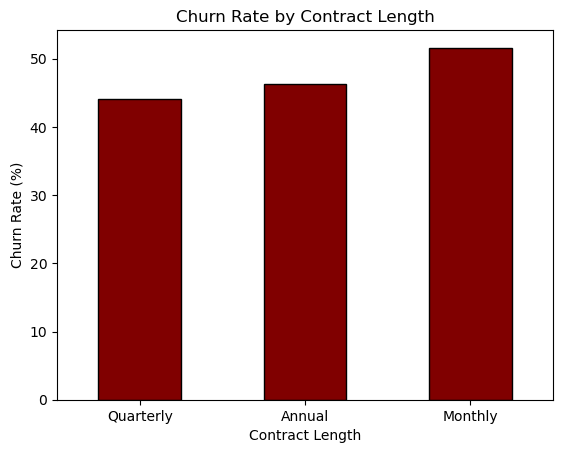

In [23]:
(customer_churn.groupby("Contract Length")["Churn"].mean()*100).sort_values().plot(kind="bar", color='maroon', edgecolor='black')
plt.title("Churn Rate by Contract Length")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

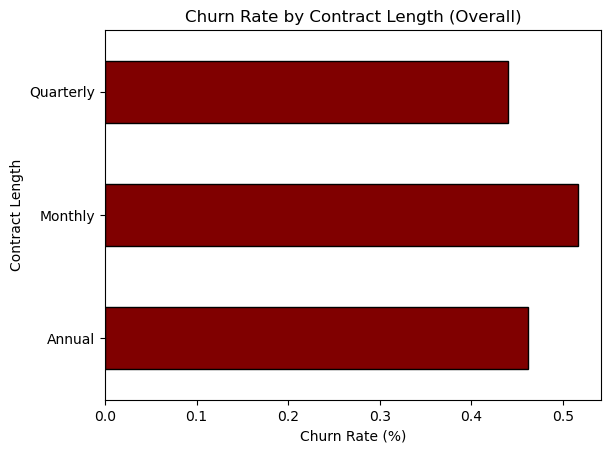

In [24]:
customer_churn.groupby("Contract Length")["Churn"].mean().plot(kind='barh', color="maroon", edgecolor='black')
plt.title('Churn Rate by Contract Length (Overall)')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Contract Length')
plt.show()

#### Which tenure months (1-60) have the highest and lowest churn rates, and does low tenure imply a high churn rate?


In [25]:
customer_churn.groupby("Tenure")["Churn"].mean().sort_values(ascending=False).head()

Tenure
37    0.586122
30    0.580699
55    0.579122
49    0.576300
43    0.575439
Name: Churn, dtype: float64

In [26]:
customer_churn.groupby("Tenure")["Churn"].mean().sort_values().head()

Tenure
16    0.264801
12    0.271538
9     0.271930
13    0.277356
19    0.278440
Name: Churn, dtype: float64

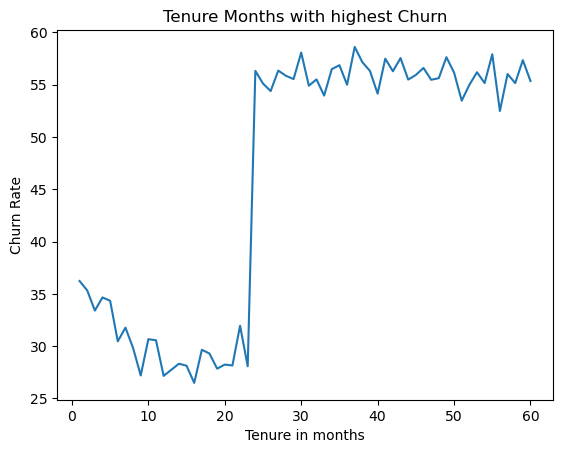

In [28]:
tenure=customer_churn.groupby("Tenure")["Churn"].mean()*100
tenure.plot(x=tenure.index, y=tenure)
plt.title("Tenure Months with highest Churn")
plt.xlabel("Tenure in months")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

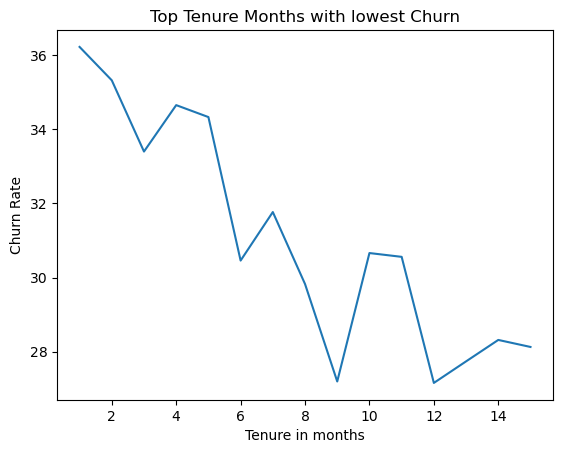

In [30]:
tenure[0:15].plot()
plt.title("Top Tenure Months with lowest Churn")
plt.xlabel("Tenure in months")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

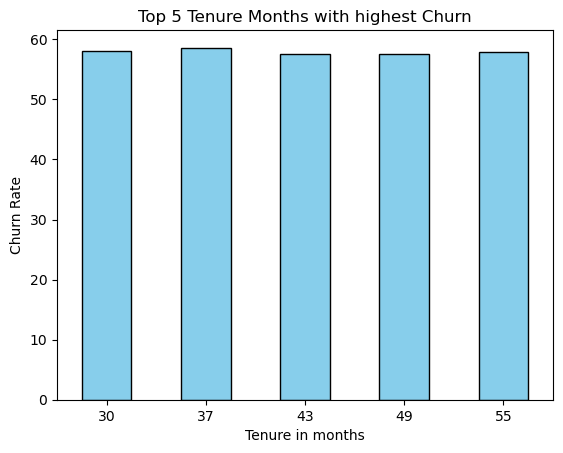

In [31]:
(customer_churn.groupby("Tenure")["Churn"].mean().sort_values(ascending=False).head().sort_index() * 100).plot( kind="bar", color="skyblue", edgecolor='black')
plt.title("Top 5 Tenure Months with highest Churn")
plt.xlabel("Tenure in months")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

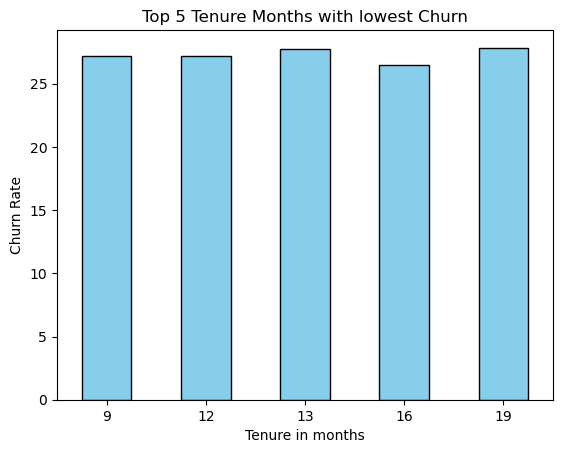

In [32]:
(customer_churn.groupby("Tenure")["Churn"].mean().sort_values().head().sort_index() * 100).plot( kind="bar", color="skyblue", edgecolor='black')
plt.title("Top 5 Tenure Months with lowest Churn")
plt.xlabel("Tenure in months")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

#### What percentage of customers had a payment delay exceeding 14 days across all customers, and how does the churn rate differ between high-delay and low-delay customers?


In [34]:
customer_churn.groupby("Payment Delay")["Churn"].mean()

Payment Delay
0     0.095985
1     0.095517
2     0.116264
3     0.107583
4     0.098237
5     0.098214
6     0.088254
7     0.107862
8     0.098781
9     0.104302
10    0.097205
11    0.105098
12    0.097038
13    0.099502
14    0.105686
15    0.101513
16    0.579348
17    0.596063
18    0.579685
19    0.582928
20    0.589912
21    0.772234
22    0.761787
23    0.778351
24    0.757278
25    0.767709
26    0.763394
27    0.762243
28    0.756420
29    0.769651
30    0.770728
Name: Churn, dtype: float64

In [35]:
customer_churn["Delay"]=customer_churn["Payment Delay"].apply(lambda x : "High" if x>=14 else "Low" )

In [36]:
customer_churn[["Delay","Payment Delay"]].head()

,Delay,Payment Delay
0,High,27
1,Low,13
2,High,29
3,High,17
4,Low,2


In [37]:
customer_churn.groupby("Delay")["Churn"].mean()

Delay
High    0.666902
Low     0.100656
Name: Churn, dtype: float64

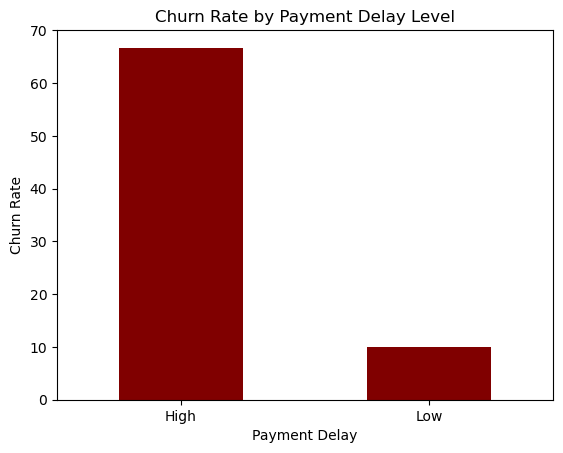

In [38]:
(customer_churn.groupby("Delay")["Churn"].mean()*100).plot(kind="bar" , color="maroon")
plt.title("Churn Rate by Payment Delay Level")
plt.xlabel("Payment Delay")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

#### How does the churn rate vary with the number of support calls (0-10), and how does it differ between customers with more than 5 calls and those with 5 or fewer?


In [39]:
customer_churn.groupby("Churn")["Support Calls"].mean()

Churn
0    4.500753
1    6.400617
Name: Support Calls, dtype: float64

In [40]:
#high=customer_churn[customer_churn["Support Calls"] > 5]
# (high.groupby("Churn").size()/customer_churn.groupby("Churn").size()*100).plot(kind="pie")

In [41]:
customer_churn["calls_level"]=customer_churn["Support Calls"].apply(lambda x : "High" if x>6 else "Low" )

In [42]:
customer_churn.groupby(["Delay","calls_level"])["Churn"].mean()

Delay  calls_level
High   High           0.817267
       Low            0.551860
Low    High           0.143403
       Low            0.075601
Name: Churn, dtype: float64

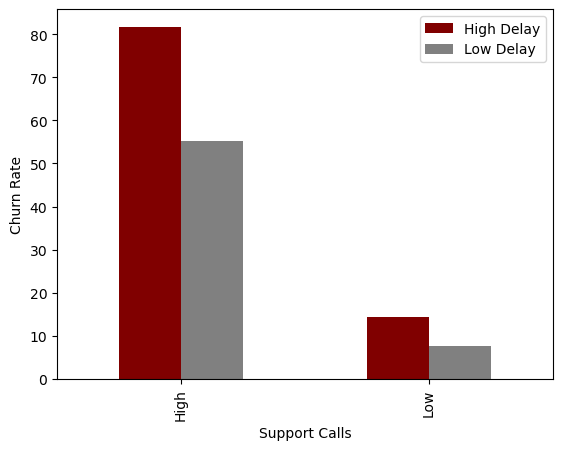

In [62]:
high = customer_churn[customer_churn["calls_level"] == "High"].groupby("Delay")["Churn"].mean()
low = customer_churn[customer_churn["calls_level"] == "Low"].groupby("Delay")["Churn"].mean()

combined = pd.DataFrame({"High Delay": high*100, "Low Delay": low*100})
combined.plot(kind="bar", color=['maroon', 'grey'])
# plt.bar(high.index, high, label='High delay', color='maroon')
# plt.bar(low.index, low, bottom=high, label='low delay', color='grey')

plt.xlabel("Support Calls")
plt.ylabel("Churn Rate")
plt.legend()
plt.show()

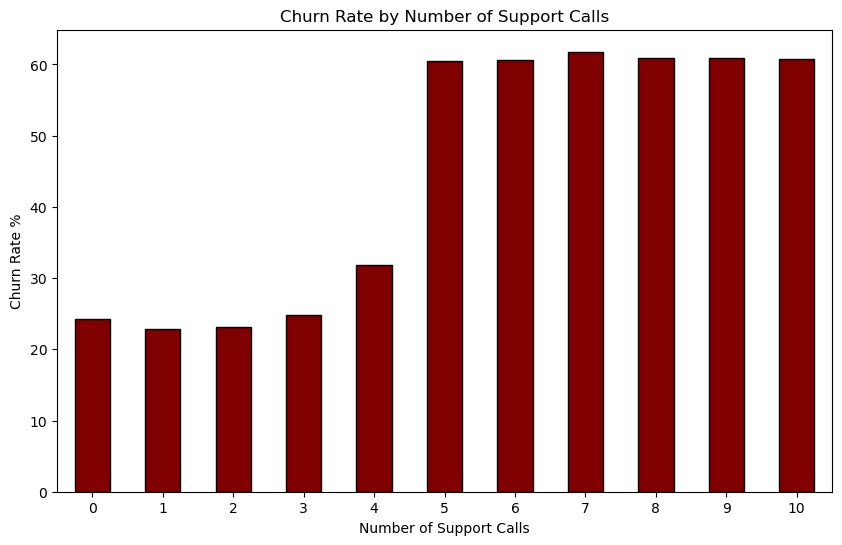

In [44]:
(customer_churn.groupby("Support Calls")["Churn"].mean() * 100).plot(
    kind='bar', color='maroon', edgecolor='black', figsize=(10,6))

plt.title("Churn Rate by Number of Support Calls")
plt.xlabel("Number of Support Calls")
plt.ylabel("Churn Rate %")
plt.xticks(rotation=0)
plt.show()

In [63]:
Basic_data = customer_churn[customer_churn["Subscription Type"] == "Basic"].groupby("Delay")["Churn"].mean()
Standard_data = customer_churn[customer_churn["Subscription Type"]== "Standard"].groupby("Delay")["Churn"].mean()
Premium_data = customer_churn[customer_churn["Subscription Type"]  == 'Premium'].groupby("Delay")["Churn"].mean()


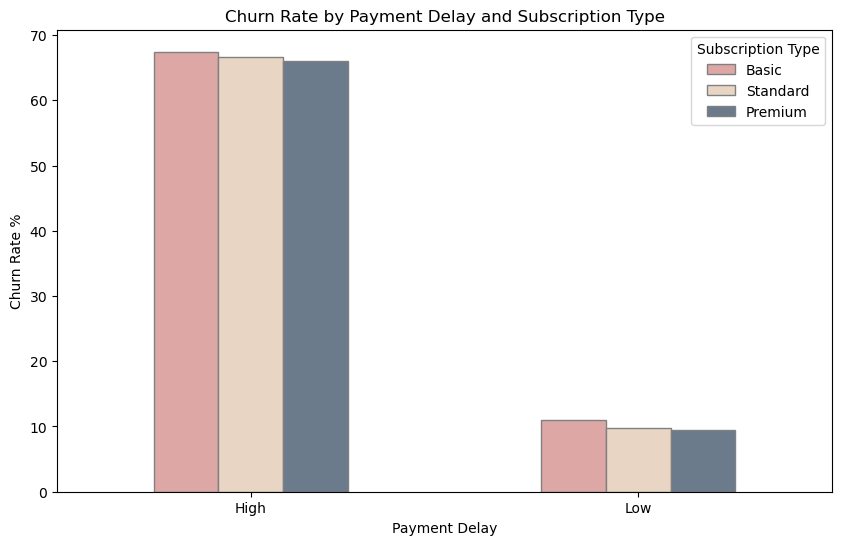

In [65]:
combined = pd.DataFrame({"Basic": Basic_data*100, "Standard": Standard_data*100, 'Premium': Premium_data*100})
combined.plot(kind='bar', color=["#DDA7A5", "#E8D5C4", "#6B7B8C"], edgecolor='grey', figsize=(10,6))

plt.title("Churn Rate by Payment Delay and Subscription Type")
plt.xlabel("Payment Delay")
plt.ylabel("Churn Rate %")
plt.legend(title="Subscription Type")
plt.xticks(rotation=0)

plt.show()

In [47]:
customer_churn.groupby("Churn")["Last Interaction"].mean()

Churn
0    15.521944
1    15.473191
Name: Last Interaction, dtype: float64

In [48]:
customer_churn.groupby("Churn")["Usage Frequency"].mean()

Churn
0    16.042915
1    14.010593
Name: Usage Frequency, dtype: float64

In [49]:
customer_churn.groupby("Churn")["Total Spend"].sum()[1]

15836117

In [50]:
#lose of this company:
(customer_churn["Total Spend"].sum())-(customer_churn.groupby("Churn")["Total Spend"].sum()[1])

18991722

In [52]:
customer_churn.to_csv("cleaned_customer_churn.csv", index=False)

## Recommendation

Monitor customers who make frequent support calls and follow up on existing issues.

Encourage customers to switch to longer-term contracts, such as annual ones.


Offer flexible payment options and reminders to customers who are more likely to be late with payments.

Offer tiered upgrades based on tenure, giving long-standing customers added value that discourages them from cancelling their subscription.
